# Advanced Computational Physics


## More about Python: Functions, Classes and Symbolic computing
### Functional programming: Functions

#### *X. Cid Vidal, J.A. Hernando Morata*, in collaboration with *G. Martínez-Lema*, *M. Kekic*.
####  USC, October 2026

In [1]:
import time
print(' Last revision ', time.asctime())

 Last revision  Mon Sep 28 12:55:39 2026


In [2]:
# general imports
%matplotlib inline

import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# possible styles: ggplot (simplicity), bmh (scientific data),
matplotlib.style.use('ggplot')

## 1. About functions

In this notebook we revisit some notions about *functions*.

A function in Python is an encapsulated piece of code that can take several arguments, performs some computations and returns a result.

The next cell shows the definition of a function, named *fib*, that returns a list with the first *n* Fibonacci numbers.

In [3]:
def fib(n):
    """ returns a list with the first n numbers of the Fibonacci series
    """
    ns = [0, 1]

    for i in range(2, n):
        ns.append(ns[i-2] + ns[i-1])

    return ns[:n]   # the slice makes fib(0) and fib(1) correct too

In [4]:
n      = 10
values = fib(n)
print(values)
print(fib(0), fib(1), fib(2))

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34]
[] [0] [0, 1]


A function has a name, *fib*, it is an object of type *function*, it can take arguments (here *n*) and it returns something (or *None*). In this case, *fib* returns a list with the first *n* Fibonacci numbers.

The expressions of the function are its body; they follow the definition of the function and they are indented.

The variables defined in the body are local and are deleted when the function ends. In this sense, a function defines its own scope (more on this in section 1.5).

In general, functions should not change the values of their arguments inside the body (see section 1.6 to understand why this can happen).

Some functions do not take arguments, or return nothing. But they are expected to do something, i.e. produce some *side effects*, such as printing or writing to an output, making plots, etc.

### 1.1 Recursion

Python supports recursion: a function can call itself. Here is the example of the function *nfactorial*, that computes the factorial of *n*.

In [5]:
def nfactorial(n):
    """ returns n! = n*(n-1)*...*1
    """
    if (n <= 1 ):
        return 1
    return n * nfactorial(n-1)

In [6]:
m = 4
print(' ' + str(m) + '! = ', nfactorial(m))
help(nfactorial)

 4! =  24
Help on function nfactorial in module __main__:

nfactorial(n)
    returns n! = n*(n-1)*...*1



Recursion in Python has two practical limitations:

 1. **Depth**: every call adds a frame to the stack, and Python stops at a (configurable) maximum depth. Unlike some functional languages, Python does *not* optimise tail calls.

 2. **Cost**: a naive recursive implementation can repeat the same work many times. The recursive Fibonacci below calls itself $\sim\phi^n$ times ($\phi \simeq 1.618$). We will fix this in section 1.5 with a cache.

In [7]:
import sys
print('maximum recursion depth:', sys.getrecursionlimit())

try:
    nfactorial(5000)
except RecursionError as error:
    print('RecursionError:', error)

maximum recursion depth: 1000
RecursionError: maximum recursion depth exceeded


In [8]:
def fib_rec(n):
    """ n-th Fibonacci number, naive recursion """
    if n < 2:
        return n
    return fib_rec(n-1) + fib_rec(n-2)

for n in (20, 25, 28):
    t0 = time.perf_counter()
    fn = fib_rec(n)
    print(f'fib_rec({n}) = {fn:8d}   took {time.perf_counter() - t0:.3f} s')

fib_rec(20) =     6765   took 0.001 s
fib_rec(25) =    75025   took 0.010 s
fib_rec(28) =   317811   took 0.040 s


### 1.2 Functions inside functions

A function can be defined inside another function. The inner function is then local, and can only be used in the scope of the outer function.

In the following example, the *distance()* function is only defined and valid inside *element_at_closest_distance_to*.

In [9]:
def element_at_closest_distance_to(x0, xs):
    """ return the element of the *xs* list that is closest to *x0*
    """
    def distance(x0, xi):
        return abs(x0 - xi)

    d, x = math.inf, None
    for xi in xs:
        di = distance(x0, xi)
        if (di < d):
            d, x = di, xi

    return x

In [10]:
x0, xs = 6j, [0., 0.5, 1j, 20.]

xi = element_at_closest_distance_to(x0, xs)

print(' closest point to x0 ', x0, ' is :', xi)

 closest point to x0  6j  is : 1j


### 1.3 Functions are objects: functions as variables and as arguments

Functions are *first-class objects*: they can be assigned to a variable, stored in a list or passed to another function.

In the following example *nf* is a variable, whose value is the function *nfactorial*.

In [11]:
ns = []
for ni in range(6):
    ns.append( nfactorial(ni) )
print('factorials ', ns)

factorials  [1, 1, 2, 6, 24, 120]


In [12]:
nf = nfactorial
ns = []
for ni in range(6):
    ns.append( nf(ni) )
print(ns)

[1, 1, 2, 6, 24, 120]


A function that takes (or returns) other functions is called a **higher-order function**. They are extremely common in numerical physics: integrators, root finders, minimisers or ODE solvers all take *the function to work on* as an argument.

Here is a minimal integrator using the midpoint rule, $\int_a^b f(x)\,dx \simeq h \sum_i f(a + (i + 1/2)\, h)$, with $h = (b-a)/n$. It works for *any* function of one variable.

In [13]:
def integrate(f, a, b, n=1000):
    """ integral of f in [a, b] using the midpoint rule with n intervals
    """
    h     = (b - a) / n
    total = 0.
    for i in range(n):
        total += f(a + (i + 0.5) * h)
    return h * total

print('int_0^pi sin(x) dx = ', integrate(math.sin, 0., math.pi))
print('int_0^1  e^x dx   = ', integrate(math.exp, 0., 1.), ' (exact:', math.e - 1, ')')

int_0^pi sin(x) dx =  2.0000008224672676
int_0^1  e^x dx   =  1.7182817568639708  (exact: 1.718281828459045 )


### 1.4 A function can return a function: closures

A function can also create and return another function.

In the following example, we pass to a function, *create_polynomial*, a list of coefficients, $[a_0, a_1, \dots, a_n]$, and it returns the actual polynomial function, $p(x)$. When called with a scalar $x$, it computes $p(x) = a_0 + a_1 \, x + a_2 \, x^2 + ... + a_n x^n = \sum_{i=0}^n a_i \, x^i$

In [14]:
def create_polynomial(coefficients):
    """ returns a function that is a polynomial with the coefficients
    given in the list coefficients
    """
    def pol(x):
        y = 0.
        for i  in range(len(coefficients)):
            y = y + coefficients[i] * (x**i)
        return y

    return pol

In [15]:
# pol is the polynomial p(x) = 1 - x + 2 x**2
coefficients = (1., -1., 2.)
x0           = 2.
pol          = create_polynomial(coefficients)

print(' pol is a : ', type(pol))
print(' is pol callable ', callable(pol))
print(' pol(x0) with x0 ', x0, ' = '  , pol(x0))

 pol is a :  <class 'function'>
 is pol callable  True
 pol(x0) with x0  2.0  =  7.0


Note that *pol* still "remembers" the value of *coefficients* after *create_polynomial* has finished. A function that carries with it variables from the scope where it was created is called a **closure**. The remembered values are stored in the function object itself:

In [16]:
print(pol.__closure__[0].cell_contents)

(1.0, -1.0, 2.0)


Also note that nothing in *pol* requires $x$ to be a number: it only needs `*`, `+` and `**` to work. So it works directly on a numpy array (this is called *duck typing*: "if it walks like a duck..."):

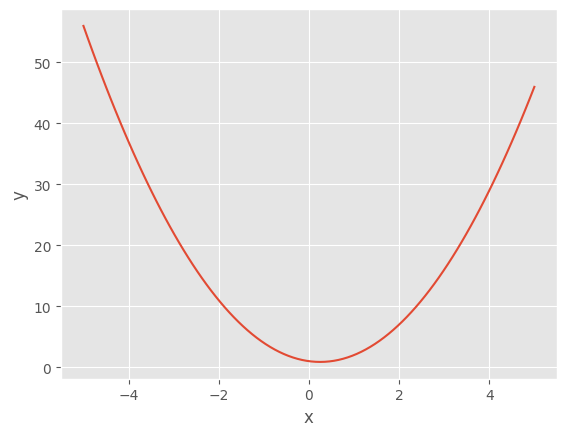

In [17]:
xs = np.linspace(-5., 5, 100)
plt.plot(xs, pol(xs));
plt.xlabel('x')
plt.ylabel('y');

### 1.5 Scope: local, enclosing, global

When Python finds a name inside a function, it looks for it in this order (the **LEGB** rule):

  1. **L**ocal: names defined in the function.
  2. **E**nclosing: names in the functions that contain it (this is what makes closures work).
  3. **G**lobal: names defined at the top level of the module (or notebook).
  4. **B**uilt-in: *print*, *len*, *sum*...

*Assigning* to a name inside a function creates a local variable, unless you declare it *global* (almost always a bad idea) or *nonlocal* (to modify a variable of the enclosing function).

In [18]:
x = 10

def f():
    x = 5          # a new local x, the global one is untouched
    return x

print(f(), x)

def make_counter():
    count = 0
    def counter():
        nonlocal count      # without this line: UnboundLocalError
        count += 1
        return count
    return counter

c1, c2 = make_counter(), make_counter()
c1(); c1()
print('c1 called', c1(), 'times; c2 called', c2(), 'times')

5 10
c1 called 3 times; c2 called 1 times


**Application: memoization.** A closure can keep a private cache of results already computed. This turns the exponential recursive Fibonacci of section 1.1 into a linear one:

In [19]:
def make_fib():
    cache = {0: 0, 1: 1}
    def fib_mem(n):
        if n not in cache:
            cache[n] = fib_mem(n-1) + fib_mem(n-2)
        return cache[n]
    return fib_mem

fib_mem = make_fib()
t0 = time.perf_counter()
print('fib_mem(28) =', fib_mem(28), f'  took {time.perf_counter() - t0:.6f} s')
print('fib_mem(200) =', fib_mem(200))

fib_mem(28) = 317811   took 0.000042 s
fib_mem(200) = 280571172992510140037611932413038677189525


The standard library already provides this: *functools.lru_cache* (and *functools.cache*). They are used as *decorators*, a syntax we will introduce in the notebook about testing.

**A classic trap: late binding.** A closure remembers the *variable*, not its value at creation time. Here all three functions see the last value of *i*:

In [20]:
multipliers = []
for i in range(3):
    multipliers.append(lambda x: i * x)      # lambda: see section 2
print('late binding :', [m(10) for m in multipliers])

# fix: freeze the current value of i as a default argument
multipliers = []
for i in range(3):
    multipliers.append(lambda x, i=i: i * x)
print('fixed        :', [m(10) for m in multipliers])

late binding : [20, 20, 20]
fixed        : [0, 10, 20]


### 1.6 Arguments are passed by reference

Python passes to the function a *reference* to the object, not a copy. If the object is **mutable** (a list, a dictionary, a numpy array...) and the function modifies it in place, the change is seen outside. Re-assigning the name inside the function, instead, only changes the local name.

In [21]:
def append_zero(xs):
    xs.append(0)          # modifies the object: visible outside

def rebind(xs):
    xs = [99]             # new local object: invisible outside

a = [1, 2]
append_zero(a)
print('after append_zero :', a)
rebind(a)
print('after rebind      :', a)

def normalize_in_place(v):
    v /= np.linalg.norm(v)     # in-place operation on a numpy array!

v = np.array([3., 4.])
normalize_in_place(v)
print('v is now          :', v)

after append_zero : [1, 2, 0]
after rebind      : [1, 2, 0]
v is now          : [0.6 0.8]


If you do not want to modify the caller's data, work on a copy (`xs = list(xs)`, `v = v.copy()`), or better, return a new object.

----
## 2. Lambda expressions

**lambda** allows you to define a small function in a single expression, on the fly, without giving it a name!

In the following example *sq* is a function defined using *lambda* that computes the square of its argument. (Assigning a lambda to a name is fine for a demo, but the style guide, PEP 8, recommends using *def* in that case.)

In [22]:
sq = lambda x : x * x
print(' sq(3) = ', sq(3.))

xs  = list(range(4))
xs2 = []
for xi in xs:
    xs2.append( sq(xi) )

print(' xs     = ', xs)
print(' sq(xs) = ', xs2)

 sq(3) =  9.0
 xs     =  [0, 1, 2, 3]
 sq(xs) =  [0, 1, 4, 9]


**lambda** functions are a common ingredient in **functional programming**.

They usually appear as arguments of other functions, like the *map()* and *filter()* builtin functions.

In the following example, *map()* applies a function defined on the fly using lambda to compute the square of the elements of the list *xs*, and produces another list with the squared values!

In [23]:
xs  = list(range(4))
xs2 = list(map(lambda x : x * x, xs))
print(' xs  =  ', xs)
print(' xs2 = ' , xs2)

 xs  =   [0, 1, 2, 3]
 xs2 =  [0, 1, 4, 9]


Here is another example: the **lambda** defines a boolean function (a *predicate*) that returns *True* if the argument is even and *False* if it is odd. Applied with *map()*, we get a list of booleans:

In [24]:
ns      = list(range(6))
is_even = lambda n: n%2 == 0
even1   = list(map(is_even              , ns))
even2   = list(map(lambda ni: ni%2 == 0 , ns))
print(' ns    ', ns)
print(' even1 ', even1)
print(' even2 ', even2)

 ns     [0, 1, 2, 3, 4, 5]
 even1  [True, False, True, False, True, False]
 even2  [True, False, True, False, True, False]


With the *filter()* builtin function, instead, the predicate is used to *select* the even numbers of the list:

In [25]:
ns2   = list(map   (lambda ni: ni * ni, ns))
evs1  = list(filter(lambda ni: ni%2 == 0, ns))

print(' ns   ', ns)
print(' ns2  ', ns2)
print(' evs1 ', evs1)

 ns    [0, 1, 2, 3, 4, 5]
 ns2   [0, 1, 4, 9, 16, 25]
 evs1  [0, 2, 4]


Many builtin functions accept a *key* function, where lambda is very handy. For instance, the function of section 1.2 can be written in one line:

In [26]:
x0, xs = 6j, [0., 0.5, 1j, 20.]
print(min(xs, key=lambda xi: abs(x0 - xi)))

1j


-----
## 3. About arguments

### 3.1 Default arguments

It is common that some arguments of a function take default values. We assign the default value, *argument = value*, in the definition of the function. If the user does not pass that argument, the function will use the default value!

In the following example, the gravitational acceleration *g* is set by default to its value on Earth.

In [27]:
def pendulum_period(L, g=9.81):
    """ small-oscillation period [s] of a pendulum of length L [m] """
    return 2 * math.pi * math.sqrt(L / g)

print('Earth: ', pendulum_period(1.))
print('Moon : ', pendulum_period(1., g=1.62))   # passing the argument by name

Earth:  2.0060666807106475
Moon :  4.93653659795374


Note: arguments with default values must go after those without them!

**A classic trap: mutable default values.** The default value is created *once*, when the function is defined, not every time the function is called. If it is mutable, it is shared between calls:

In [28]:
def add_measurement(x, data=[]):
    data.append(x)
    return data

print(add_measurement(1.))
print(add_measurement(2.))     # surprise!

# the standard fix: use None as default and create the object inside
def add_measurement(x, data=None):
    if data is None:
        data = []
    data.append(x)
    return data

print(add_measurement(1.))
print(add_measurement(2.))

[1.0]
[1.0, 2.0]
[1.0]
[2.0]


### 3.2 Arguments from a list or tuple

You can pass several arguments to a function using a list or a tuple. In order to unpack it, just use the * operator in front!

In [29]:
def prod(a, b):
    return a * b

## note the * notation!
x = [3, -1]
print(prod(*x))

-3


A function can also return several objects. They are returned as a *tuple*, that can be used either as a tuple or unpacked into individual variables.

In [30]:
def total_and_delta(a, b):
    return a + b, a - b

a, b = 4, 1.
cc = total_and_delta(a, b)
print(type(cc))
print(cc)
total, delta = total_and_delta(a, b)
print('total ', total, ', delta', delta)

<class 'tuple'>
(5.0, 3.0)
total  5.0 , delta 3.0


In [31]:
cc  = total_and_delta(a, b)
print('total ', cc[0], ', delta', cc[1])

total  5.0 , delta 3.0


### 3.3 Arguments from a dictionary

You can also pass the arguments to a function using a dictionary. In that case the keys of the dictionary should be strings identical to the names of the arguments of the function. You need to use the double ** operator in front of the dictionary!

In [32]:
def print_client_phone(client, phone):
    print(' client ', client, ' phone ', phone)

In [33]:
print_client_phone('Perico', 66123153)

 client  Perico  phone  66123153


In [34]:
data = {'client' : 'Perico', 'phone' : 22123123}
# note ** notation
print_client_phone(**data)

 client  Perico  phone  22123123


### 3.4 Variable number of arguments: *args and **kwargs

The same * and ** operators can be used in the *definition* of a function. Then the function accepts any number of positional arguments, collected in a tuple (conventionally called *args*), and/or any number of keyword arguments, collected in a dictionary (*kwargs*).

In [35]:
def show_arguments(*args, **kwargs):
    print(' args   =', args)
    print(' kwargs =', kwargs)

show_arguments(1, 2., 'three', mass=0.511, charge=-1)

 args   = (1, 2.0, 'three')
 kwargs = {'mass': 0.511, 'charge': -1}


This is very useful to write generic code that *passes the parameters through* to another function, without knowing them in advance:

In [36]:
def evaluate(f, xs, *args, **kwargs):
    """ evaluates f(x, *args, **kwargs) for each x in xs """
    ys = []
    for x in xs:
        ys.append(f(x, *args, **kwargs))
    return ys

def harmonic(x, k=1., x0=0.):
    """ harmonic potential """
    return 0.5 * k * (x - x0)**2

print(evaluate(harmonic, [0., 1., 2.]))
print(evaluate(harmonic, [0., 1., 2.], 4.))            # k = 4
print(evaluate(harmonic, [0., 1., 2.], k=4., x0=1.))

[0.0, 0.5, 2.0]
[0.0, 2.0, 8.0]
[2.0, 0.0, 2.0]


Arguments placed after a bare `*` in the definition are **keyword-only**: they must be passed by name. This avoids mistakes with functions that have many parameters of the same type. (Similarly, arguments before a `/` are *positional-only*.)

In [37]:
def gaussian(x, *, mu=0., sigma=1.):
    return math.exp(-0.5 * ((x - mu) / sigma)**2) / (sigma * math.sqrt(2 * math.pi))

print(gaussian(1., mu=0., sigma=2.))
try:
    gaussian(1., 0., 2.)          # is 2. the mean or the sigma? Python refuses to guess
except TypeError as error:
    print('TypeError:', error)

0.17603266338214976
TypeError: gaussian() takes 1 positional argument but 3 were given


### 3.5 Fixing arguments: functools.partial

Frequently a tool (like our *integrate* of section 1.3, or the scipy integrators and minimisers) wants a function of a single variable, $f(x)$, but our function has parameters, $V(x; k, x_0)$. *functools.partial* creates a new function with some of the arguments already fixed:

In [38]:
from functools import partial

V = partial(harmonic, k=4., x0=1.)     # V(x) = harmonic(x, k=4., x0=1.)
print(V(2.), harmonic(2., k=4., x0=1.))
print('int_0^2 V(x) dx =', integrate(V, 0., 2.), ' (exact: 4/3)')

2.0 2.0
int_0^2 V(x) dx = 1.3333320000000004  (exact: 4/3)


The same could be done with a closure or a lambda, `lambda x: harmonic(x, k=4., x0=1.)`, but *partial* is more explicit (and, unlike lambdas, partial objects can be sent to other processes, which matters for multiprocessing).

### 3.6 Type hints

Python only requires that the arguments of a function support the operations used in its body: arguments are 'generic'.

Some programmers consider this a disadvantage. You can *annotate* the arguments and the return value with their expected types to make the code more readable (see the *typing* and *collections.abc* modules).

In [39]:
from collections.abc import Callable

def create_polynomial(coefficients: tuple[float, ...]) -> Callable[[float], float]:
    """ returns a function that is a polynomial with the coefficients given in the tuple coefficients
    """
    def pol(x: float) -> float:
        y = 0.
        for i  in range(len(coefficients)):
            y = y + coefficients[i] * (x**i)
        return y
    return pol

print(create_polynomial.__annotations__)

{'coefficients': tuple[float, ...], 'return': collections.abc.Callable[[float], float]}


**Important**: annotations are *not* checked by Python at run time. They are documentation for humans, editors and external tools like *mypy*, which check them without running the code. Here the wrong call is accepted, and it only fails later, when the polynomial is evaluated:

In [40]:
cas = (1., 1., 1.)
pol = create_polynomial(cas)
print(pol(1.))

pol_bad = create_polynomial(1)          # wrong type, but no error here...
try:
    pol_bad(1.)                          # ... the error appears only when len(1) is evaluated
except TypeError as error:
    print('TypeError:', error)

3.0
TypeError: object of type 'int' has no len()


----
## Summary

  1. Functions are objects: they can be stored in variables, passed to other functions and returned by functions.
  2. Functions can be recursive, but Python limits the recursion depth and naive recursion can be very expensive.
  3. A function created inside another one is a *closure*: it remembers the variables of the enclosing scope (LEGB rule, *nonlocal*).
  4. Arguments are passed by reference: mutable arguments can be modified by the function.
  5. *lambda* creates small anonymous functions, typically used with *map*, *filter* or as *key* functions.
  6. Default arguments are evaluated only once: never use a mutable default.
  7. `*args`, `**kwargs`, keyword-only arguments and *functools.partial* give flexible interfaces.
  8. Type hints document the code, but they are not enforced at run time.

### Exercises

  1. Define a function to compute the mean and the variance of a list of numbers, without numpy. Check the result with numpy.


  2. Define the Poisson probability function, $p(n | \mu) = \mu^n e^{-\mu} / n!$. 

      * Define a function that, given the mean value $\mu$ of a Poisson distribution, returns a function $f(n)$ such that $f(n) = p(n | \mu)$ (a closure). Check that $\sum_{n=0}^{50} f(n) \simeq 1$ for $\mu = 5$.


  3. Numerical derivatives with closures. Write `derivative(f, h=1e-5)` that returns a *function* approximating $f'(x)$ with the central difference $[f(x+h) - f(x-h)]/2h$. Check that the derivative of `math.sin` is `math.cos`.

      * Add an optional argument `method` (`'forward'` or `'central'`) and print the error at $x=1$ for $h = 10^{-1}, 10^{-2}, \dots, 10^{-8}$. Which method is more accurate?